<a href="https://colab.research.google.com/github/plnu-biomechanics/kin4042/blob/main/notebooks/kin4042_lab2_key.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://www.pointloma.edu/sites/default/files/styles/basic_page/public/images/PLNU_Biomechanics_Lab_green_yellowSD_HiRes.png" width="400">

# KIN 4042 Sport Informatics
## Lab 2: Between-session reliability of CMJ performance and asymmetry

**Instructor:** Arnel Aguinaldo, PhD

In this lab, you will reproduce the principal summary and reliability analyses from:

Pérez-Castilla, A., García-Ramos, A., Janicijevic, D., Delgado-García, G., De la Cruz, J. C., Rojas, F. J., & Cepero, M. (2021). Between-session reliability of performance and asymmetry variables obtained during unilateral and bilateral countermovement jumps in basketball players. *PLOS ONE, 16*(7), e0255458. https://doi.org/10.1371/journal.pone.0255458

Twenty-three basketball players completed two identical CMJ testing sessions separated by seven days. The notebook uses the public, athlete-level supporting dataset.

## Learning objectives

By the end of this lab, you should be able to:

1. import and audit repeated-measures sport-performance data;
2. reshape a dataset between wide and long formats;
3. calculate signed inter-limb asymmetry;
4. summarize performance and asymmetry by session;
5. choose between a paired *t* test and Wilcoxon signed-rank test;
6. calculate Cohen's *d*, SEM-based coefficient of variation (CV), and ICC(3,1);
7. interpret absolute and relative reliability together.

> **Replication note:** The public CSV contains rounded values. Small differences from the published table are expected. It also does not identify each player's preferred leg. Therefore, unilateral asymmetry can be reproduced directly, whereas the paper's preference-leg coding for bilateral asymmetry cannot be reconstructed exactly.

## 1. Import the Python libraries

### ✋ Suggested GenAI prompt — Import the analysis libraries

> I am working in Google Colab on a repeated-measures CMJ reliability lab. Generate one Python code cell that imports pathlib, urllib.request, NumPy, pandas, Matplotlib, seaborn, scipy.stats, sklearn's cohen_kappa_score, and IPython.display.display. Set useful pandas display options and a readable seaborn theme. Use only packages normally available in Colab and briefly explain what each library contributes.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [1]:
# Core libraries available in Google Colab; no additional installation is required.
import os
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.metrics import cohen_kappa_score
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid", context="notebook")

## 2. Download and load the data

The code downloads the CSV into the temporary Colab runtime. If the GitHub URL is unavailable, upload the CSV into the same folder and rerun the loading cell.

### ✋ Suggested GenAI prompt — Create a folder and download the dataset

> Generate Python code for Google Colab that creates the folder kin4042/lab2 with pathlib, then downloads pone_0255458_s001.csv from the PLNU Biomechanics Lab GitHub raw URL into that folder using urllib.request. The code should be safe to rerun and should print the completed file path.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [2]:
data_dir = Path("kin4042/lab2")
data_dir.mkdir(parents=True, exist_ok=True)

data_url = (
    "https://raw.githubusercontent.com/plnu-biomechanics/"
    "kin4042/refs/heads/main/labs/pone_0255458_s001.csv"
)
data_path = data_dir / "pone_0255458_s001.csv"

urllib.request.urlretrieve(data_url, data_path)
print(f"Downloaded: {data_path}")

Downloaded: kin4042/lab2/pone_0255458_s001.csv


### ✋ Suggested GenAI prompt — Load and clean the CSV

> Load the CMJ CSV into a pandas DataFrame named cmj. Read it with utf-8-sig encoding, replace hyphens in all column names with underscores, sort rows by Code and Session, reset the index, and display the shape and first five rows. Explain why utf-8-sig and standardized column names are useful.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [3]:
# utf-8-sig safely removes the byte-order mark found in the original CSV.
cmj = pd.read_csv(data_path, encoding="utf-8-sig")

# Replace hyphens in column names such as CI-UNICMJ_RIGHT.
cmj.columns = cmj.columns.str.replace("-", "_", regex=False)
cmj = cmj.sort_values(["Code", "Session"]).reset_index(drop=True)

print(f"Shape: {cmj.shape}")
display(cmj.head())

Shape: (46, 32)


,Code,Session,MF_UNICMJ_RIGHT,PF_UNICMJ_RIGHT,MV_UNICMJ_RIGHT,PV_UNICMJ_RIGHT,MP_UNICMJ_RIGHT,PP_UNICMJ_RIGHT,CI_UNICMJ_RIGHT,JH_UNICMJ_RIGHT,MF_UNICMJ_LEFT,PF_UNICMJ_LEFT,MV_UNICMJ_LEFT,PV_UNICMJ_LEFT,MP_UNICMJ_LEFT,PP_UNICMJ_LEFT,CI_UNICMJ_LEFT,JH_UNICMJ_LEFT,MF_BICMJ_RIGHT,PF_BICMJ_RIGHT,MV_BICMJ_RIGHT,PV_BICMJ_RIGHT,MP_BICMJ_RIGHT,PP_BICMJ_RIGHT,CI_BICMJ_RIGHT,MF_BICMJ_LEFT,PF_BICMJ_LEFT,MV_BICMJ_LEFT,PV_BICMJ_LEFT,MP_BICMJ_LEFT,PP_BICMJ_LEFT,CI_BICMJ_LEFT
0,1,1,1126.2,1379.4,1.22,2.10,1254.2,2396.2,134.1,0.19,1122.7,1388.6,1.21,2.09,1233.7,2421.5,130.2,0.18,666.4,786.9,1.55,2.75,952.2,1891.2,94.2,616.7,756.4,1.06,1.87,600.4,1245.0,65.8
1,1,2,1179.8,1617.9,1.24,2.00,1278.3,2497.3,121.1,0.14,1126.6,1479.2,1.16,1.91,1161.9,2173.2,115.8,0.15,636.2,808.3,1.60,2.90,939.9,2019.1,94.0,564.7,735.8,0.71,1.27,367.6,796.6,41.5
2,2,1,1127.5,1308.5,1.20,2.06,1242.9,2329.0,138.4,0.15,1104.2,1354.7,1.10,2.01,1141.5,2342.8,132.8,0.18,850.8,1025.2,1.76,2.92,1329.6,2194.8,109.4,676.6,831.9,1.65,2.89,1027.4,1862.0,102.0
3,2,2,1239.9,1479.2,1.20,2.03,1348.4,2470.2,139.1,0.22,1338.7,1602.0,1.16,2.05,1373.6,2546.1,157.6,0.18,891.7,1081.1,1.72,2.87,1366.8,2284.5,109.7,802.7,992.5,1.60,2.68,1143.3,1932.1,94.6
4,3,1,1034.0,1265.5,1.29,2.15,1224.2,2036.3,130.6,0.25,1029.3,1176.2,1.30,2.33,1254.6,2357.1,140.9,0.25,653.4,821.2,1.88,3.18,1117.0,1843.5,102.1,643.1,773.7,1.40,2.67,813.2,1621.6,92.1


### Data audit

### ✋ Suggested GenAI prompt — Audit the repeated-measures dataset

> Using the pandas DataFrame cmj, generate code that reports the number of rows, columns, unique players, unique sessions, missing cells, and players with two sessions. Add assertions that confirm 46 rows, 23 players, sessions 1 and 2, two sessions per player, and no missing values. Make any failed check return an informative message.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [4]:
sessions_per_player = cmj.groupby("Code")["Session"].nunique()

audit = pd.Series({
    "rows": len(cmj),
    "columns": cmj.shape[1],
    "unique_players": cmj["Code"].nunique(),
    "unique_sessions": cmj["Session"].nunique(),
    "missing_cells": int(cmj.isna().sum().sum()),
    "players_with_two_sessions": int((sessions_per_player == 2).sum()),
}, name="Value").to_frame()

display(audit)

assert len(cmj) == 46, "Expected 46 rows."
assert cmj["Code"].nunique() == 23, "Expected 23 players."
assert set(cmj["Session"].unique()) == {1, 2}, "Expected sessions 1 and 2."
assert sessions_per_player.eq(2).all(), "Every player must have two sessions."
assert cmj.isna().sum().sum() == 0, "Unexpected missing data found."

print("Data audit passed.")

,Value
rows,46
columns,32
unique_players,23
unique_sessions,2
missing_cells,0
players_with_two_sessions,23


Data audit passed.


## 3. Reshape and summarize the performance variables

Variable prefixes:

| Prefix | Metric | Unit |
|---|---|---|
| MF | Mean force | N |
| PF | Peak force | N |
| MV | Mean velocity | m/s |
| PV | Peak velocity | m/s |
| MP | Mean power | W |
| PP | Peak power | W |
| CI | Concentric impulse | N·s |
| JH | Jump height | m |

`UNICMJ` denotes a unilateral CMJ; `BICMJ` denotes a bilateral CMJ. The final component identifies the right or left limb.

### ✋ Suggested GenAI prompt — Reshape performance data to long format

> The DataFrame cmj has Code and Session identifiers and CMJ columns named like MF_UNICMJ_RIGHT. Generate pandas code that reshapes all performance columns to long format with Variable and Value columns. Parse Variable into Metric, Jump, and Limb using a regular expression; recode UNICMJ and BICMJ to readable labels; and display eight rows. Preserve Code and Session.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [5]:
id_columns = ["Code", "Session"]
performance_columns = [column for column in cmj.columns if column not in id_columns]

performance_long = cmj.melt(
    id_vars=id_columns,
    value_vars=performance_columns,
    var_name="Variable",
    value_name="Value",
)

components = performance_long["Variable"].str.extract(
    r"^(?P<Metric>[A-Z]+)_(?P<Jump>UNICMJ|BICMJ)_(?P<Limb>RIGHT|LEFT)$"
)
performance_long = pd.concat([performance_long, components], axis=1)
performance_long["Jump"] = performance_long["Jump"].map({
    "UNICMJ": "Unilateral CMJ",
    "BICMJ": "Bilateral CMJ",
})
performance_long["Limb"] = performance_long["Limb"].str.title()

display(performance_long.head(8))

,Code,Session,Variable,Value,Metric,Jump,Limb
0,1,1,MF_UNICMJ_RIGHT,1126.2,MF,Unilateral CMJ,Right
1,1,2,MF_UNICMJ_RIGHT,1179.8,MF,Unilateral CMJ,Right
2,2,1,MF_UNICMJ_RIGHT,1127.5,MF,Unilateral CMJ,Right
3,2,2,MF_UNICMJ_RIGHT,1239.9,MF,Unilateral CMJ,Right
4,3,1,MF_UNICMJ_RIGHT,1034.0,MF,Unilateral CMJ,Right
5,3,2,MF_UNICMJ_RIGHT,1044.1,MF,Unilateral CMJ,Right
6,4,1,MF_UNICMJ_RIGHT,1052.0,MF,Unilateral CMJ,Right
7,4,2,MF_UNICMJ_RIGHT,1092.1,MF,Unilateral CMJ,Right


### ✋ Suggested GenAI prompt — Calculate descriptive statistics

> Using performance_long, calculate n, mean, sample standard deviation, minimum, and maximum for every Jump × Metric × Limb × Session combination. Return a tidy DataFrame named performance_summary and display a formatted pandas Styler table with two decimal places.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [6]:
performance_summary = (
    performance_long
    .groupby(["Jump", "Metric", "Limb", "Session"], as_index=False)
    .agg(
        n=("Value", "count"),
        Mean=("Value", "mean"),
        SD=("Value", "std"),
        Minimum=("Value", "min"),
        Maximum=("Value", "max"),
    )
)

display(
    performance_summary.style
    .format({"Mean": "{:.2f}", "SD": "{:.2f}", "Minimum": "{:.2f}", "Maximum": "{:.2f}"})
    .set_caption("CMJ performance by session")
)

,Jump,Metric,Limb,Session,n,Mean,SD,Minimum,Maximum
0,Bilateral CMJ,CI,Left,1,23,85.95,26.27,42.50,152.20
1,Bilateral CMJ,CI,Left,2,23,82.38,24.67,34.20,142.70
2,Bilateral CMJ,CI,Right,1,23,89.24,27.98,41.60,143.10
3,Bilateral CMJ,CI,Right,2,23,92.95,29.14,49.00,163.00
4,Bilateral CMJ,MF,Left,1,23,653.12,90.86,470.70,845.80
5,Bilateral CMJ,MF,Left,2,23,659.74,90.99,525.80,834.00
6,Bilateral CMJ,MF,Right,1,23,661.06,103.72,430.60,863.10
7,Bilateral CMJ,MF,Right,2,23,663.60,102.14,487.50,891.70
8,Bilateral CMJ,MP,Left,1,23,834.93,284.87,374.70,1349.90
9,Bilateral CMJ,MP,Left,2,23,817.24,294.97,348.10,1357.10


### Visualize paired session values

### ✋ Suggested GenAI prompt — Create a paired session plot

> Generate Matplotlib code that lets me choose one CMJ variable by changing a selected_variable string. Plot Session 1 and Session 2 values, connect the same player with a light line, overlay colored points, label both axes, and add a title. Use Code to group the paired observations and the cmj DataFrame as input.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

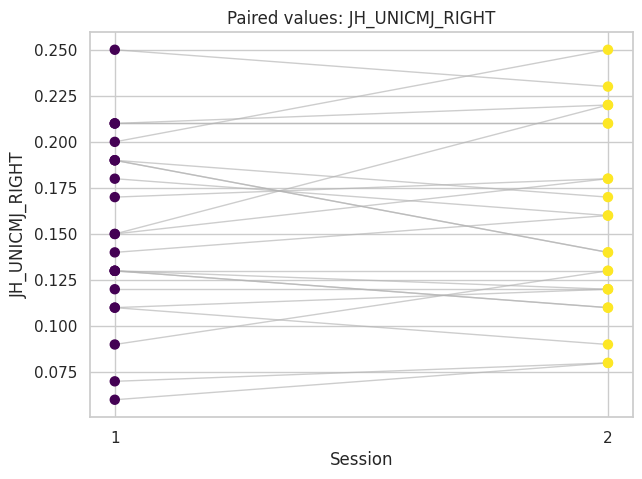

In [7]:
# Change this string to inspect a different variable.
selected_variable = "JH_UNICMJ_RIGHT"

selected = cmj[["Code", "Session", selected_variable]].copy()

fig, ax = plt.subplots(figsize=(7, 5))
for _, player in selected.groupby("Code"):
    ax.plot(player["Session"], player[selected_variable], color="0.70", alpha=0.65, linewidth=1)
ax.scatter(selected["Session"], selected[selected_variable], c=selected["Session"],
           cmap="viridis", s=42, zorder=3)
ax.set(xticks=[1, 2], xlabel="Session", ylabel=selected_variable,
       title=f"Paired values: {selected_variable}")
plt.show()

## 4. Calculate inter-limb asymmetry

For unilateral CMJs, the article used the percentage-difference formula

$$
100\left(1-\frac{\min(R,L)}{\max(R,L)}\right).
$$

We add a sign so that positive scores indicate a larger right-leg value and negative scores indicate a larger left-leg value:

$$
\text{signed unilateral asymmetry}=100\frac{R-L}{\max(R,L)}.
$$

### ✋ Suggested GenAI prompt — Calculate inter-limb asymmetry variables

> Create vectorized Python functions for two inter-limb asymmetry calculations. For unilateral CMJ, calculate signed percentage difference as 100*(right-left)/max(right,left), where positive favors right. For bilateral CMJ, calculate unsigned magnitude as 100*abs(right-left)/(right+left). Return NaN when the denominator is zero. Apply the functions to MF, PF, MV, PV, MP, PP, and CI; also calculate unilateral JH asymmetry. Add the new columns to cmj_analysis.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [8]:
def signed_unilateral_asymmetry(right, left):
    # Signed percentage difference: positive favors right, negative favors left.
    denominator = np.maximum(right, left)
    return np.where(denominator == 0, np.nan, 100 * (right - left) / denominator)


def bilateral_asymmetry_magnitude(right, left):
    # Unsigned bilateral asymmetry magnitude; does not require preferred leg.
    denominator = right + left
    return np.where(denominator == 0, np.nan, 100 * np.abs(right - left) / denominator)


metric_codes = ["MF", "PF", "MV", "PV", "MP", "PP", "CI"]
cmj_analysis = cmj.copy()

for metric in metric_codes:
    cmj_analysis[f"ASYM_{metric}_UNICMJ"] = signed_unilateral_asymmetry(
        cmj_analysis[f"{metric}_UNICMJ_RIGHT"],
        cmj_analysis[f"{metric}_UNICMJ_LEFT"],
    )
    cmj_analysis[f"ASYM_{metric}_BICMJ_MAG"] = bilateral_asymmetry_magnitude(
        cmj_analysis[f"{metric}_BICMJ_RIGHT"],
        cmj_analysis[f"{metric}_BICMJ_LEFT"],
    )

# Jump height was reported only for unilateral CMJs.
cmj_analysis["ASYM_JH_UNICMJ"] = signed_unilateral_asymmetry(
    cmj_analysis["JH_UNICMJ_RIGHT"],
    cmj_analysis["JH_UNICMJ_LEFT"],
)

unilateral_asymmetry_columns = [
    column for column in cmj_analysis.columns
    if column.startswith("ASYM_") and column.endswith("_UNICMJ")
]
bilateral_magnitude_columns = [
    column for column in cmj_analysis.columns
    if column.startswith("ASYM_") and column.endswith("_BICMJ_MAG")
]

display(cmj_analysis[["Code", "Session"] + unilateral_asymmetry_columns].head())

,Code,Session,ASYM_MF_UNICMJ,ASYM_PF_UNICMJ,ASYM_MV_UNICMJ,ASYM_PV_UNICMJ,ASYM_MP_UNICMJ,ASYM_PP_UNICMJ,ASYM_CI_UNICMJ,ASYM_JH_UNICMJ
0,1,1,0.311,-0.663,0.820,0.476,1.635,-1.045,2.908,5.263
1,1,2,4.509,8.573,6.452,4.500,9.106,12.978,4.377,-6.667
2,2,1,2.067,-3.410,8.333,2.427,8.158,-0.589,4.046,-16.667
3,2,2,-7.380,-7.665,3.333,-0.976,-1.835,-2.981,-11.739,18.182
4,3,1,0.455,7.056,-0.769,-7.725,-2.423,-13.610,-7.310,0.000


### ✋ Suggested GenAI prompt — Summarize the asymmetry variables

> Reshape the asymmetry columns in cmj_analysis to a long DataFrame with Code, Session, Variable, and Asymmetry. Label unilateral signed asymmetry separately from the bilateral magnitude extension, extract the metric code, and calculate n, mean, sample SD, minimum, and maximum by analysis, metric, and session. Display a formatted table with two decimals.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [9]:
asymmetry_long = cmj_analysis.melt(
    id_vars=["Code", "Session"],
    value_vars=unilateral_asymmetry_columns + bilateral_magnitude_columns,
    var_name="Variable",
    value_name="Asymmetry",
)
asymmetry_long["Analysis"] = np.where(
    asymmetry_long["Variable"].str.endswith("_BICMJ_MAG"),
    "Bilateral magnitude (extension)",
    "Unilateral signed asymmetry",
)
asymmetry_long["Metric"] = asymmetry_long["Variable"].str.extract(r"^ASYM_([A-Z]+)_")

asymmetry_summary = (
    asymmetry_long
    .groupby(["Analysis", "Metric", "Session"], as_index=False)
    .agg(
        n=("Asymmetry", "count"),
        Mean=("Asymmetry", "mean"),
        SD=("Asymmetry", "std"),
        Minimum=("Asymmetry", "min"),
        Maximum=("Asymmetry", "max"),
    )
)

display(
    asymmetry_summary.style
    .format({"Mean": "{:.2f}", "SD": "{:.2f}", "Minimum": "{:.2f}", "Maximum": "{:.2f}"})
    .set_caption("Inter-limb asymmetry by session")
)

,Analysis,Metric,Session,n,Mean,SD,Minimum,Maximum
0,Bilateral magnitude (extension),CI,1,23,16.94,12.29,0.89,40.78
1,Bilateral magnitude (extension),CI,2,23,15.82,14.59,1.01,62.64
2,Bilateral magnitude (extension),MF,1,23,3.13,2.25,0.24,11.41
3,Bilateral magnitude (extension),MF,2,23,3.10,2.01,0.35,6.18
4,Bilateral magnitude (extension),MP,1,23,21.83,11.96,0.32,45.79
5,Bilateral magnitude (extension),MP,2,23,21.77,17.25,2.18,69.21
6,Bilateral magnitude (extension),MV,1,23,19.86,11.58,1.09,42.86
7,Bilateral magnitude (extension),MV,2,23,19.32,16.09,1.85,64.82
8,Bilateral magnitude (extension),PF,1,23,2.77,2.24,0.61,10.41
9,Bilateral magnitude (extension),PF,2,23,2.34,1.69,0.06,5.39


## 5. Reliability-analysis functions

For each variable, we will calculate:

- a paired *t* test when paired differences are normally distributed, or a Wilcoxon signed-rank test otherwise;
- Cohen's *d* using $(M_2-M_1)/SD_{pooled}$, matching the article's definition;
- SEM and CV from the residual error of a two-way subject-by-session ANOVA;
- ICC(3,1): two-way mixed-effects, consistency, single measure;
- 95% confidence intervals for CV and ICC.

The article classified a performance metric as acceptable when **ICC > 0.70 and CV < 10%**. CV is not used for signed asymmetry because its mean can approach zero.

### ✋ Suggested GenAI prompt — Build reusable reliability functions

> Write reusable Python functions for a two-session reliability analysis. First, pivot one variable into complete, player-aligned Session 1 and Session 2 arrays. Then calculate ICC(3,1) from a two-way mixed-effects consistency, single-measure model using ANOVA mean squares and an F-based 95% CI. Finally, create a wrapper that tests the normality of paired differences, selects a paired t test or Wilcoxon signed-rank test, calculates pooled-SD Cohen's d, SEM, CV=100*SEM/mean, a chi-square 95% CI for CV, and returns all results as a dictionary. Allow CV to be omitted for signed asymmetry.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [10]:
def make_pairs(data, variable):
    # Return complete Session 1 and Session 2 arrays aligned by player.
    paired = (
        data[["Code", "Session", variable]]
        .pivot(index="Code", columns="Session", values=variable)
        .dropna(subset=[1, 2])
        .sort_index()
    )
    return paired[1].to_numpy(float), paired[2].to_numpy(float)


def icc_3_1(session_1, session_2, alpha=0.05):
    # ICC(3,1): two-way mixed, consistency, single-measure ICC.
    values = np.column_stack([session_1, session_2])
    n, k = values.shape
    grand_mean = values.mean()
    subject_means = values.mean(axis=1)
    session_means = values.mean(axis=0)

    ss_subject = k * np.sum((subject_means - grand_mean) ** 2)
    residuals = values - subject_means[:, None] - session_means[None, :] + grand_mean
    ss_error = np.sum(residuals ** 2)

    df_subject = n - 1
    df_error = (n - 1) * (k - 1)
    ms_subject = ss_subject / df_subject
    ms_error = ss_error / df_error

    icc = (ms_subject - ms_error) / (ms_subject + (k - 1) * ms_error)

    # F-based confidence interval for ICC(C,1). Spreadsheet/package conventions
    # can produce slightly different limits, but the point estimate is identical.
    f_ratio = ms_subject / ms_error
    f_lower = f_ratio / stats.f.ppf(1 - alpha / 2, df_subject, df_error)
    f_upper = f_ratio * stats.f.ppf(1 - alpha / 2, df_error, df_subject)
    icc_low = (f_lower - 1) / (f_lower + k - 1)
    icc_high = (f_upper - 1) / (f_upper + k - 1)

    return {
        "ICC_3_1": icc,
        "ICC_low": icc_low,
        "ICC_high": icc_high,
        "MS_error": ms_error,
        "df_error": df_error,
    }


def analyze_reliability(data, variable, report_cv=True):
    session_1, session_2 = make_pairs(data, variable)
    difference = session_2 - session_1
    n = len(difference)

    shapiro = stats.shapiro(difference)
    if shapiro.pvalue > 0.05:
        comparison = stats.ttest_rel(session_2, session_1)
        test_name = "Paired t test"
    else:
        comparison = stats.wilcoxon(session_2, session_1, method="approx", correction=False)
        test_name = "Wilcoxon signed-rank"

    pooled_sd = np.sqrt((np.var(session_1, ddof=1) + np.var(session_2, ddof=1)) / 2)
    cohens_d = (np.mean(session_2) - np.mean(session_1)) / pooled_sd

    icc = icc_3_1(session_1, session_2)
    sem = np.sqrt(icc["MS_error"])

    if report_cv:
        mean_score = np.mean(np.concatenate([session_1, session_2]))
        cv = 100 * sem / mean_score
        df_error = icc["df_error"]
        cv_low = cv * np.sqrt(df_error / stats.chi2.ppf(0.975, df_error))
        cv_high = cv * np.sqrt(df_error / stats.chi2.ppf(0.025, df_error))
    else:
        sem = cv = cv_low = cv_high = np.nan

    return {
        "Variable": variable,
        "n": n,
        "Session_1_Mean": np.mean(session_1),
        "Session_1_SD": np.std(session_1, ddof=1),
        "Session_2_Mean": np.mean(session_2),
        "Session_2_SD": np.std(session_2, ddof=1),
        "Test": test_name,
        "Normality_p": shapiro.pvalue,
        "Comparison_p": comparison.pvalue,
        "Cohens_d": cohens_d,
        "SEM": sem,
        "CV": cv,
        "CV_low": cv_low,
        "CV_high": cv_high,
        "ICC_3_1": icc["ICC_3_1"],
        "ICC_low": icc["ICC_low"],
        "ICC_high": icc["ICC_high"],
    }

## 6. Check normality of paired differences

A paired *t* test assumes that the **within-player differences** are normally distributed. It does not require each session by itself to be normal.

### ✋ Suggested GenAI prompt — Test normality of paired differences

> For every performance variable and unilateral asymmetry variable in cmj_analysis, align Session 1 and Session 2 by Code and run a Shapiro-Wilk test on Session 2 minus Session 1. Create a table containing Variable, n, W, p, and a recommended paired t test when p>.05 or Wilcoxon signed-rank test otherwise. Explain why the paired differences—not each session separately—are tested.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [11]:
analysis_variables = performance_columns + unilateral_asymmetry_columns

normality_results = []
for variable in analysis_variables:
    session_1, session_2 = make_pairs(cmj_analysis, variable)
    result = stats.shapiro(session_2 - session_1)
    normality_results.append({
        "Variable": variable,
        "n": len(session_1),
        "W": result.statistic,
        "p": result.pvalue,
        "Recommended_test": "Paired t test" if result.pvalue > 0.05 else "Wilcoxon signed-rank",
    })

normality_results = pd.DataFrame(normality_results)
display(
    normality_results.style
    .format({"W": "{:.3f}", "p": "{:.3f}"})
    .set_caption("Shapiro-Wilk tests of paired differences")
)

,Variable,n,W,p,Recommended_test
0,MF_UNICMJ_RIGHT,23,0.961,0.491,Paired t test
1,PF_UNICMJ_RIGHT,23,0.942,0.197,Paired t test
2,MV_UNICMJ_RIGHT,23,0.963,0.524,Paired t test
3,PV_UNICMJ_RIGHT,23,0.987,0.988,Paired t test
4,MP_UNICMJ_RIGHT,23,0.985,0.975,Paired t test
5,PP_UNICMJ_RIGHT,23,0.924,0.080,Paired t test
6,CI_UNICMJ_RIGHT,23,0.939,0.175,Paired t test
7,JH_UNICMJ_RIGHT,23,0.958,0.423,Paired t test
8,MF_UNICMJ_LEFT,23,0.937,0.156,Paired t test
9,PF_UNICMJ_LEFT,23,0.986,0.982,Paired t test


## 7. Performance reliability

### ✋ Suggested GenAI prompt — Analyze performance reliability

> Apply my analyze_reliability function to every CMJ performance column. Add Jump, Limb, and Metric labels parsed from each column name. Classify reliability as Acceptable only when ICC(3,1)>.70 and CV<10%; otherwise label it Review. Display session means and SDs, test, p, Cohen's d, CV with 95% CI, ICC with 95% CI, and the classification in a formatted table. Highlight rows needing review.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [12]:
performance_reliability = pd.DataFrame([
    analyze_reliability(cmj_analysis, variable, report_cv=True)
    for variable in performance_columns
])

performance_reliability["Jump"] = np.select(
    [
        performance_reliability["Variable"].str.contains("_UNICMJ_"),
        performance_reliability["Variable"].str.contains("_BICMJ_"),
    ],
    ["Unilateral CMJ", "Bilateral CMJ"],
    default="Unknown",
)
performance_reliability["Limb"] = np.where(
    performance_reliability["Variable"].str.endswith("_RIGHT"), "Right", "Left"
)
performance_reliability["Metric"] = performance_reliability["Variable"].str.extract(r"^([A-Z]+)")
performance_reliability["Reliability"] = np.where(
    (performance_reliability["ICC_3_1"] > 0.70) & (performance_reliability["CV"] < 10),
    "Acceptable",
    "Review",
)

performance_table = performance_reliability[[
    "Jump", "Metric", "Limb", "n",
    "Session_1_Mean", "Session_1_SD", "Session_2_Mean", "Session_2_SD",
    "Test", "Comparison_p", "Cohens_d", "CV", "CV_low", "CV_high",
    "ICC_3_1", "ICC_low", "ICC_high", "Reliability",
]].copy()

display(
    performance_table.style
    .format({
        "Session_1_Mean": "{:.2f}", "Session_1_SD": "{:.2f}",
        "Session_2_Mean": "{:.2f}", "Session_2_SD": "{:.2f}",
        "Comparison_p": "{:.3f}", "Cohens_d": "{:.2f}",
        "CV": "{:.2f}", "CV_low": "{:.2f}", "CV_high": "{:.2f}",
        "ICC_3_1": "{:.2f}", "ICC_low": "{:.2f}", "ICC_high": "{:.2f}",
    })
    .map(lambda value: "background-color: #fff2cc" if value == "Review" else "",
         subset=["Reliability"])
    .set_caption("Between-session reliability of CMJ performance")
)

,Jump,Metric,Limb,n,Session_1_Mean,Session_1_SD,Session_2_Mean,Session_2_SD,Test,Comparison_p,Cohens_d,CV,CV_low,CV_high,ICC_3_1,ICC_low,ICC_high,Reliability
0,Unilateral CMJ,MF,Right,23,1061.24,159.09,1082.48,162.51,Paired t test,0.221,0.13,5.34,4.13,7.55,0.87,0.73,0.94,Acceptable
1,Unilateral CMJ,PF,Right,23,1306.05,195.55,1325.94,225.75,Paired t test,0.480,0.09,7.14,5.52,10.10,0.80,0.59,0.91,Acceptable
2,Unilateral CMJ,MV,Right,23,1.04,0.18,1.08,0.19,Paired t test,0.026,0.26,6.22,4.81,8.80,0.87,0.71,0.94,Acceptable
3,Unilateral CMJ,PV,Right,23,1.86,0.27,1.88,0.29,Paired t test,0.418,0.07,4.10,3.17,5.81,0.92,0.83,0.97,Acceptable
4,Unilateral CMJ,MP,Right,23,1037.18,270.83,1092.80,286.12,Paired t test,0.025,0.20,7.34,5.68,10.39,0.92,0.82,0.97,Acceptable
5,Unilateral CMJ,PP,Right,23,2047.83,489.75,2078.90,539.98,Paired t test,0.469,0.06,6.93,5.36,9.81,0.92,0.83,0.97,Acceptable
6,Unilateral CMJ,CI,Right,23,121.43,29.40,120.75,26.97,Paired t test,0.785,-0.02,6.87,5.31,9.72,0.91,0.81,0.96,Acceptable
7,Unilateral CMJ,JH,Right,23,0.15,0.05,0.15,0.05,Paired t test,0.777,0.03,13.33,10.31,18.87,0.83,0.64,0.92,Review
8,Unilateral CMJ,MF,Left,23,1050.99,162.33,1098.80,173.03,Paired t test,0.003,0.28,4.45,3.44,6.30,0.92,0.82,0.96,Acceptable
9,Unilateral CMJ,PF,Left,23,1275.45,208.36,1328.40,229.25,Paired t test,0.010,0.24,4.92,3.80,6.96,0.91,0.81,0.96,Acceptable


## 8. Unilateral asymmetry reliability

The paper reported ICC, but not CV, for asymmetry. CV would be unstable when the signed group mean is close to zero.

### ✋ Suggested GenAI prompt — Analyze unilateral asymmetry reliability

> Apply my analyze_reliability function to all signed unilateral asymmetry columns, with CV disabled because signed means may approach zero. Extract the metric code, classify ICC values above .70 as acceptable, and display session means and SDs, selected paired test, p, Cohen's d, ICC(3,1), and its 95% CI. Highlight unacceptable ICCs.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [13]:
asymmetry_reliability = pd.DataFrame([
    analyze_reliability(cmj_analysis, variable, report_cv=False)
    for variable in unilateral_asymmetry_columns
])
asymmetry_reliability["Metric"] = asymmetry_reliability["Variable"].str.extract(
    r"^ASYM_([A-Z]+)_"
)
asymmetry_reliability["ICC_interpretation"] = np.where(
    asymmetry_reliability["ICC_3_1"] > 0.70, "Acceptable", "Unacceptable"
)

asymmetry_table = asymmetry_reliability[[
    "Metric", "n", "Session_1_Mean", "Session_1_SD", "Session_2_Mean",
    "Session_2_SD", "Test", "Comparison_p", "Cohens_d",
    "ICC_3_1", "ICC_low", "ICC_high", "ICC_interpretation",
]]

display(
    asymmetry_table.style
    .format({
        "Session_1_Mean": "{:.2f}", "Session_1_SD": "{:.2f}",
        "Session_2_Mean": "{:.2f}", "Session_2_SD": "{:.2f}",
        "Comparison_p": "{:.3f}", "Cohens_d": "{:.2f}",
        "ICC_3_1": "{:.2f}", "ICC_low": "{:.2f}", "ICC_high": "{:.2f}",
    })
    .map(lambda value: "background-color: #fff2cc" if value == "Unacceptable" else "",
         subset=["ICC_interpretation"])
    .set_caption("Between-session reliability of unilateral CMJ asymmetry")
)

,Metric,n,Session_1_Mean,Session_1_SD,Session_2_Mean,Session_2_SD,Test,Comparison_p,Cohens_d,ICC_3_1,ICC_low,ICC_high,ICC_interpretation
0,MF,23,0.93,7.67,-1.35,4.66,Paired t test,0.151,-0.36,0.33,-0.09,0.65,Unacceptable
1,PF,23,2.36,6.94,-0.13,5.25,Paired t test,0.153,-0.40,0.14,-0.28,0.52,Unacceptable
2,MV,23,-0.21,8.33,2.29,9.38,Paired t test,0.293,0.28,0.21,-0.21,0.57,Unacceptable
3,PV,23,-0.64,8.57,1.79,6.71,Paired t test,0.097,0.32,0.62,0.28,0.82,Unacceptable
4,MP,23,-0.04,12.40,0.93,10.34,Paired t test,0.691,0.08,0.49,0.11,0.75,Unacceptable
5,PP,23,0.23,12.80,2.55,8.02,Paired t test,0.287,0.22,0.54,0.18,0.78,Unacceptable
6,CI,23,-2.68,13.50,-0.72,9.52,Paired t test,0.439,0.17,0.48,0.09,0.74,Unacceptable
7,JH,23,-5.27,16.91,-3.75,12.91,Wilcoxon signed-rank,0.931,0.10,0.42,0.02,0.70,Unacceptable


### Direction-of-asymmetry agreement

ICC evaluates the consistency of asymmetry **scores**. Cohen's kappa evaluates whether the same side was favored in both sessions. The article interpreted kappa as poor (≤0), slight (.01–.20), fair (.21–.40), moderate (.41–.60), substantial (.61–.80), or almost perfect (.81–.99).

### ✋ Suggested GenAI prompt — Evaluate direction-of-asymmetry agreement

> For each signed unilateral asymmetry variable, code nonnegative scores as Right and negative scores as Left for each session. Calculate Cohen's kappa between sessions, count how many players favor the same side twice, and classify kappa as poor, slight, fair, moderate, substantial, or almost perfect using the Landis and Koch ranges supplied in the lab. Return and display a tidy results table.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [14]:
def interpret_kappa(value):
    if value <= 0.00:
        return "Poor"
    if value <= 0.20:
        return "Slight"
    if value <= 0.40:
        return "Fair"
    if value <= 0.60:
        return "Moderate"
    if value <= 0.80:
        return "Substantial"
    return "Almost perfect"


kappa_results = []
for variable in unilateral_asymmetry_columns:
    session_1, session_2 = make_pairs(cmj_analysis, variable)
    direction_1 = np.where(session_1 >= 0, "Right", "Left")
    direction_2 = np.where(session_2 >= 0, "Right", "Left")
    kappa = cohen_kappa_score(direction_1, direction_2)
    kappa_results.append({
        "Metric": variable.split("_")[1],
        "Kappa": kappa,
        "Agreement": interpret_kappa(kappa),
        "Same_direction_n": int(np.sum(direction_1 == direction_2)),
        "Total_n": len(direction_1),
    })

kappa_results = pd.DataFrame(kappa_results)
display(
    kappa_results.style
    .format({"Kappa": "{:.2f}"})
    .set_caption("Agreement in the direction of unilateral CMJ asymmetry")
)

,Metric,Kappa,Agreement,Same_direction_n,Total_n
0,MF,0.15,Slight,13,23
1,PF,0.12,Slight,13,23
2,MV,0.09,Slight,13,23
3,PV,0.12,Slight,13,23
4,MP,-0.04,Poor,11,23
5,PP,-0.03,Poor,11,23
6,CI,-0.10,Poor,11,23
7,JH,0.30,Fair,15,23


## 9. Optional extension: bilateral asymmetry magnitude

The dataset does not contain preferred-leg identity, so this is an **unsigned magnitude analysis** rather than an exact reproduction of the paper's bilateral preference-leg analysis. Do not compare these ICCs directly with the paper's bilateral asymmetry ICCs.

### ✋ Suggested GenAI prompt — Analyze bilateral asymmetry magnitude

> As a clearly labeled extension, apply the reliability function to the unsigned bilateral asymmetry-magnitude variables. Do not calculate CV. Display session means and SDs, test, p, Cohen's d, ICC(3,1), and its 95% CI. Add a note that these results cannot reproduce preference-leg asymmetry because preferred-leg identity is missing from the public dataset.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [15]:
bilateral_magnitude_reliability = pd.DataFrame([
    analyze_reliability(cmj_analysis, variable, report_cv=False)
    for variable in bilateral_magnitude_columns
])
bilateral_magnitude_reliability["Metric"] = bilateral_magnitude_reliability["Variable"].str.extract(
    r"^ASYM_([A-Z]+)_"
)

display(
    bilateral_magnitude_reliability[[
        "Metric", "n", "Session_1_Mean", "Session_1_SD", "Session_2_Mean",
        "Session_2_SD", "Test", "Comparison_p", "Cohens_d",
        "ICC_3_1", "ICC_low", "ICC_high",
    ]].style
    .format({
        "Session_1_Mean": "{:.2f}", "Session_1_SD": "{:.2f}",
        "Session_2_Mean": "{:.2f}", "Session_2_SD": "{:.2f}",
        "Comparison_p": "{:.3f}", "Cohens_d": "{:.2f}",
        "ICC_3_1": "{:.2f}", "ICC_low": "{:.2f}", "ICC_high": "{:.2f}",
    })
    .set_caption("Extension: bilateral CMJ asymmetry magnitude")
)

,Metric,n,Session_1_Mean,Session_1_SD,Session_2_Mean,Session_2_SD,Test,Comparison_p,Cohens_d,ICC_3_1,ICC_low,ICC_high
0,MF,23,3.13,2.25,3.10,2.01,Paired t test,0.948,-0.02,0.33,-0.09,0.65
1,PF,23,2.77,2.24,2.34,1.69,Paired t test,0.417,-0.22,0.22,-0.20,0.57
2,MV,23,19.86,11.58,19.32,16.09,Paired t test,0.803,-0.04,0.72,0.45,0.87
3,PV,23,20.34,13.27,18.70,16.46,Paired t test,0.461,-0.11,0.75,0.50,0.89
4,MP,23,21.83,11.96,21.77,17.25,Paired t test,0.980,-0.00,0.71,0.44,0.87
5,PP,23,21.57,13.60,20.33,16.83,Paired t test,0.599,-0.08,0.73,0.47,0.88
6,CI,23,16.94,12.29,15.82,14.59,Paired t test,0.623,-0.08,0.68,0.38,0.85


## 10. Verification checks

### ✋ Suggested GenAI prompt — Add verification checks

> Write Python assertions that confirm the calculated public-CSV results for MF_UNICMJ_RIGHT are approximately ICC(3,1)=0.87350, CV=5.33608%, and paired-test p=.22122, and that MF_UNICMJ_LEFT is approximately ICC=.91879 and CV=4.44766%. Use np.isclose with a sensible tolerance and print a success message only when all checks pass.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [16]:
# These checks verify the analysis against values independently calculated from
# the public CSV. They prevent silent errors if the code is modified.
check_right = performance_reliability.loc[
    performance_reliability["Variable"] == "MF_UNICMJ_RIGHT"
].iloc[0]
check_left = performance_reliability.loc[
    performance_reliability["Variable"] == "MF_UNICMJ_LEFT"
].iloc[0]

assert np.isclose(check_right["ICC_3_1"], 0.87350, atol=1e-4)
assert np.isclose(check_right["CV"], 5.33608, atol=1e-4)
assert np.isclose(check_right["Comparison_p"], 0.22122, atol=1e-4)
assert np.isclose(check_left["ICC_3_1"], 0.91879, atol=1e-4)
assert np.isclose(check_left["CV"], 4.44766, atol=1e-4)

print("Verification checks passed.")

Verification checks passed.


## 11. Interpretation questions

1. Why should ICC and CV be interpreted together rather than separately?
2. Which performance variables met both criteria for acceptable reliability?
3. Did jump height show the same reliability as force, velocity, power, or impulse?
4. Which unilateral asymmetry metric had the highest ICC? Did any exceed .70?
5. Did the favored limb remain consistent between sessions according to kappa?
6. Why is CV misleading for a signed variable with a mean close to zero?
7. What does a non-significant paired comparison tell you? Why does it **not** prove reliability?
8. Compare your results with Table 2 of Pérez-Castilla et al. (2021). How might rounding, normality-test decisions, confidence-interval conventions, and missing preferred-leg metadata explain differences?

## 12. Save the analysis tables

### ✋ Suggested GenAI prompt — Export the analysis tables

> Create a kin4042/lab2/outputs folder that is safe to recreate. Export the performance summary, asymmetry summary, performance reliability, unilateral asymmetry reliability, and unilateral kappa DataFrames as CSV files without row indices. Finally, print the names of every CSV saved in the folder.

After generating the code, compare it with the guide cell below, run it, and confirm that the output is reasonable. Add a comment naming the agent that assisted you, for example:

```python
# =======================================
# Code generated or assisted by [agent]
# =======================================
```

In [17]:
output_dir = data_dir / "outputs"
output_dir.mkdir(exist_ok=True)

performance_summary.to_csv(output_dir / "performance_summary.csv", index=False)
asymmetry_summary.to_csv(output_dir / "asymmetry_summary.csv", index=False)
performance_reliability.to_csv(output_dir / "performance_reliability.csv", index=False)
asymmetry_reliability.to_csv(output_dir / "unilateral_asymmetry_reliability.csv", index=False)
kappa_results.to_csv(output_dir / "unilateral_asymmetry_kappa.csv", index=False)

print("Saved files:")
for path in sorted(output_dir.glob("*.csv")):
    print(f"- {path}")

Saved files:
- kin4042/lab2/outputs/asymmetry_summary.csv
- kin4042/lab2/outputs/performance_reliability.csv
- kin4042/lab2/outputs/performance_summary.csv
- kin4042/lab2/outputs/unilateral_asymmetry_kappa.csv
- kin4042/lab2/outputs/unilateral_asymmetry_reliability.csv


## Final note

Reliability is multidimensional. A metric can show a high ICC because players maintain their rank order, yet still have enough within-player noise to produce an unacceptable CV. Conversely, the absence of a significant session difference does not establish reliability. Interpret systematic change, standardized effect size, absolute error, relative reliability, and direction-of-asymmetry agreement together.